# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, \
                            ConfusionMatrixDisplay, classification_report, accuracy_score, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

In [3]:
real_test = pd.read_csv("./data/test.csv", encoding="latin-1")

In [4]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [6]:
from toolbox_ml.eda.core import tipifica_variables, describe_df, get_features_cat_regression, \
    get_features_num_regression, plot_features_cat_regression, plot_features_num_regression, verificar_dataframe

In [7]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
laptop_ID,int64,0.0,912,100.00
Company,object,0.0,19,2.08
Product,object,0.0,480,52.63
TypeName,object,0.0,6,0.66
Inches,float64,0.0,17,1.86
ScreenResolution,object,0.0,36,3.95
Cpu,object,0.0,107,11.73
Ram,object,0.0,9,0.99
Memory,object,0.0,37,4.06
Gpu,object,0.0,93,10.20


In [8]:
tipifica_variables(df)

,nombre_variable,tipo_sugerido
0,laptop_ID,Numérica Continua
1,Company,Numérica Discreta
2,Product,Numérica Discreta
3,TypeName,Categórica
4,Inches,Numérica Discreta
5,ScreenResolution,Numérica Discreta
6,Cpu,Numérica Discreta
7,Ram,Categórica
8,Memory,Numérica Discreta
9,Gpu,Numérica Discreta


### 2.1 Exploración de los datos

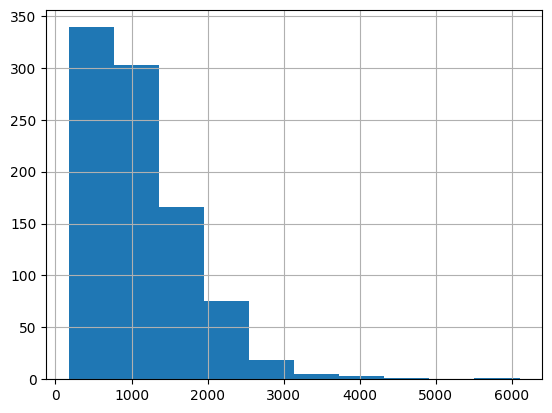

In [9]:
target = "Price_in_euros"
df[target].hist();

### 2.2 Dividir en train y test

In [10]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

### Variable `target`

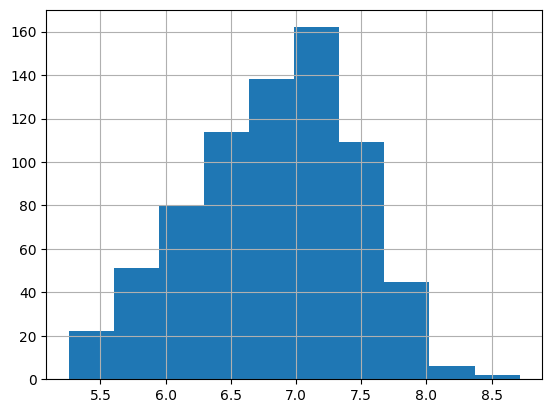

In [11]:
train_set[target].transform("log").hist();

In [12]:
train_set[target + "_log"] = train_set[target].transform("log")
test_set[target + "_log"] = test_set[target].transform("log")

In [13]:
original_target = target
target = target + "_log"

## Features

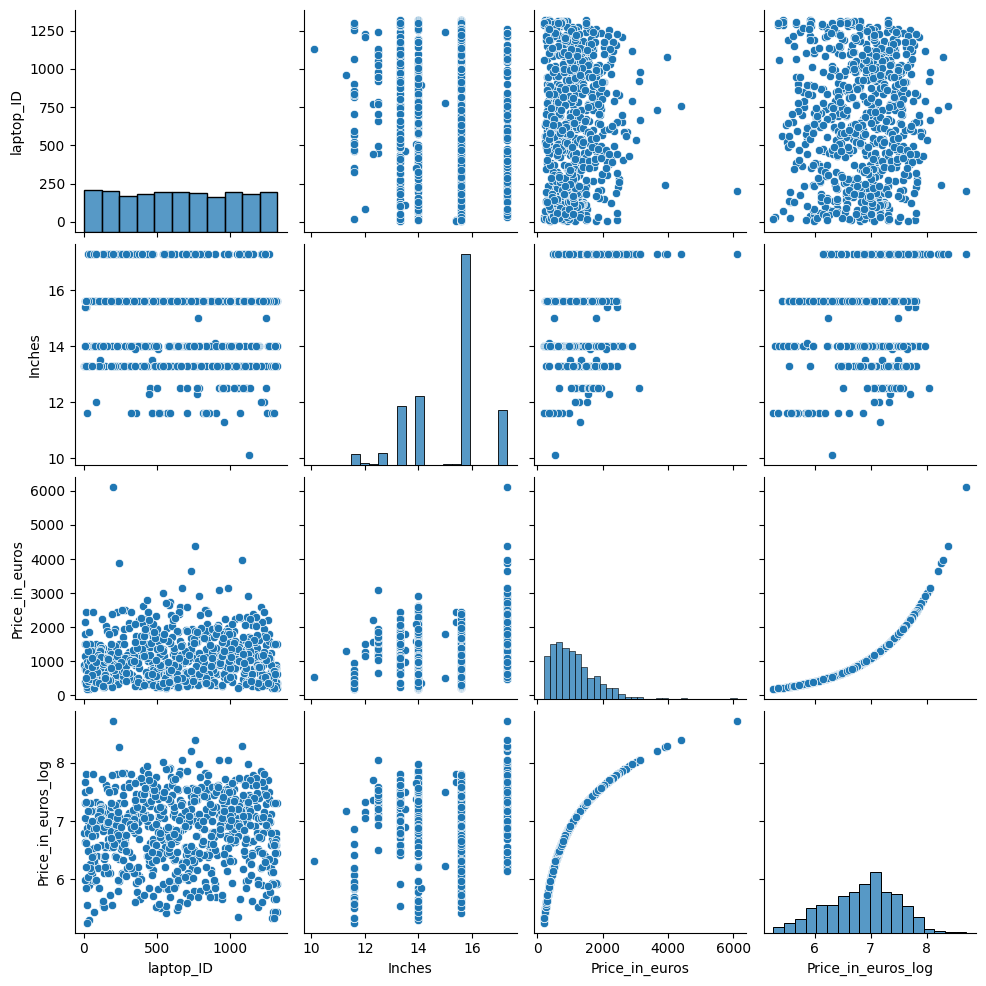

In [14]:
sns.pairplot(train_set);

In [15]:
df_tipos = tipifica_variables(df)
df_tipos.loc[df_tipos.tipo_sugerido.isin(["Numérica Discreta", "Numérica Continua"])]

,nombre_variable,tipo_sugerido
0,laptop_ID,Numérica Continua
1,Company,Numérica Discreta
2,Product,Numérica Discreta
4,Inches,Numérica Discreta
5,ScreenResolution,Numérica Discreta
6,Cpu,Numérica Discreta
8,Memory,Numérica Discreta
9,Gpu,Numérica Discreta
11,Weight,Numérica Discreta
12,Price_in_euros,Numérica Discreta


In [16]:
vars_num = df_tipos.loc[df_tipos.tipo_sugerido.isin(["Numérica Discreta", "Numérica Continua"]), "nombre_variable"].tolist()
vars_cat = df_tipos.loc[df_tipos.tipo_sugerido.isin(["Binaria", "Categórica"]), "nombre_variable"].tolist()

train_set.dtypes

laptop_ID               int64
Company                object
Product                object
TypeName               object
Inches                float64
ScreenResolution       object
Cpu                    object
Ram                    object
Memory                 object
Gpu                    object
OpSys                  object
Weight                 object
Price_in_euros        float64
Price_in_euros_log    float64
dtype: object

Sacamos las variables con datos de tipo `object` para ver si necesitan ser procesadas.

In [17]:
raw_vars = [var for var in train_set.columns if train_set[var].dtype == object]
raw_vars

['Company',
 'Product',
 'TypeName',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Memory',
 'Gpu',
 'OpSys',
 'Weight']

In [18]:
# Contrastamos con los resultados obtenidos por su cardinalidad
vars_cat, "",  vars_num

(['TypeName', 'Ram', 'OpSys'],
 '',
 ['laptop_ID',
  'Company',
  'Product',
  'Inches',
  'ScreenResolution',
  'Cpu',
  'Memory',
  'Gpu',
  'Weight',
  'Price_in_euros'])

In [19]:
raw_num = list(set(raw_vars)&set(vars_num))
raw_cat = list(set(raw_vars)&set(vars_cat))

raw_num, "", raw_cat

(['Product', 'Cpu', 'Weight', 'ScreenResolution', 'Memory', 'Gpu', 'Company'],
 '',
 ['TypeName', 'Ram', 'OpSys'])

Vamos a limpiar las variables de texto, a ver si sacamos alguna cosa interesante.

In [20]:
for var in raw_cat:
    print(train_set[var].value_counts(True), end="\n"*2)

TypeName
Notebook              0.565158
Gaming                0.155007
Ultrabook             0.155007
2 in 1 Convertible    0.085048
Netbook               0.021948
Workstation           0.017833
Name: proportion, dtype: float64

Ram
8GB     0.466392
4GB     0.297668
16GB    0.153635
6GB     0.027435
12GB    0.024691
2GB     0.020576
32GB    0.008230
64GB    0.001372
Name: proportion, dtype: float64

OpSys
Windows 10      0.817558
No OS           0.053498
Linux           0.050754
Windows 7       0.032922
Chrome OS       0.019204
macOS           0.009602
Mac OS X        0.008230
Windows 10 S    0.006859
Android         0.001372
Name: proportion, dtype: float64



In [21]:
# Veamos si son significativas
get_features_cat_regression(train_set, target)

['TypeName', 'Ram', 'OpSys']

In [22]:
# Vamos a ir guardando los nombres de las variables
features = []

#### Variable `TypeName`

In [23]:
from scipy.stats import mannwhitneyu
var_cat = "TypeName"
clases = [clase for clase in train_set[var_cat].unique()]
grupos = [train_set.loc[train_set[var_cat] == clase][target] for clase in clases]
pobs_significativas = set()

for i, grupo1 in enumerate(grupos):
    for j in range(i+1, len(grupos)):
        u_stat, p_valor = mannwhitneyu(grupo1, grupos[j])
        if p_valor < 0.05:
            pobs_significativas.add(tuple(set([clases[i], clases[j]])))

In [24]:
pobs_significativas

{('Gaming', '2 in 1 Convertible'),
 ('Gaming', 'Netbook'),
 ('Gaming', 'Notebook'),
 ('Netbook', '2 in 1 Convertible'),
 ('Netbook', 'Notebook'),
 ('Notebook', '2 in 1 Convertible'),
 ('Ultrabook', 'Netbook'),
 ('Ultrabook', 'Notebook'),
 ('Workstation', '2 in 1 Convertible'),
 ('Workstation', 'Gaming'),
 ('Workstation', 'Netbook'),
 ('Workstation', 'Notebook'),
 ('Workstation', 'Ultrabook')}

No parece ayudar mucho, veamos los boxplots.

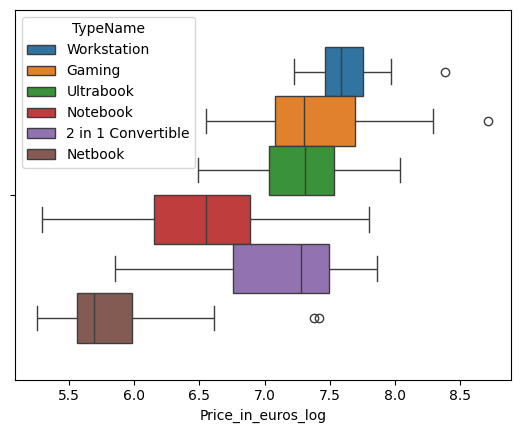

In [25]:
sns.boxplot(train_set, x=target, hue="TypeName", orient="Vertical");

Vamos a hacer un ordinal encoding según el final de la cola del RIC.

In [26]:
from scipy.stats import iqr
q3 = train_set.groupby("TypeName")[target].quantile(0.75)

iqr = train_set.groupby("TypeName")[target].agg(iqr)

upper_inner_fence = q3 + 1.5 * iqr

orden_TypeName = upper_inner_fence.sort_values(ascending=False).index.tolist()
orden_TypeName

['Gaming',
 '2 in 1 Convertible',
 'Ultrabook',
 'Workstation',
 'Notebook',
 'Netbook']

In [27]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
train_set["ordinal_TypeName"] = ordinal_encoder.fit_transform(train_set[["TypeName"]])
test_set["ordinal_TypeName"] = ordinal_encoder.transform(test_set[["TypeName"]]) 
real_test["ordinal_TypeName"] = ordinal_encoder.transform(real_test[["TypeName"]])

In [28]:
train_set["ordinal_TypeName"].value_counts(dropna=False)

ordinal_TypeName
3.0    412
1.0    113
4.0    113
0.0     62
2.0     16
5.0     13
Name: count, dtype: int64

In [29]:
# comprobamos que está bien codificada
for tipo, indice in enumerate(orden_TypeName):
    print(all((train_set["ordinal_TypeName"]==i+1) == (train_set["TypeName"]==tipo)))

True
True
True
True
True
True


In [30]:
features.append("ordinal_TypeName")

#### Variable `OpSys`
Vamos a agruparla por marcas y ver si hay diferencia.

In [31]:
# Windows
train_set["OpSys_Windows"] = train_set.OpSys.str.contains("Windows", regex=False).astype(int)
test_set["OpSys_Windows"] = test_set.OpSys.str.contains("Windows", regex=False).astype(int)
real_test["OpSys_Windows"] = real_test.OpSys.str.contains("Windows", regex=False).astype(int)

train_set.OpSys_Windows.value_counts(True)

OpSys_Windows
1    0.857339
0    0.142661
Name: proportion, dtype: float64

In [32]:
# MacOS
train_set["OpSys_Mac"] = train_set.OpSys.str.contains("mac", case=False, regex=False).astype(int)
test_set["OpSys_Mac"] = test_set.OpSys.str.contains("mac", case=False, regex=False).astype(int)
real_test["OpSys_Mac"] = real_test.OpSys.str.contains("mac", case=False, regex=False).astype(int)

train_set.OpSys_Mac.value_counts(True)

OpSys_Mac
0    0.982167
1    0.017833
Name: proportion, dtype: float64

In [33]:
# Linux
train_set["OpSys_Linux"] = (train_set.OpSys == "Linux").astype(int)
test_set["OpSys_Linux"] = (test_set.OpSys == "Linux").astype(int)
real_test["OpSys_Linux"] = (real_test.OpSys == "Linux").astype(int)

train_set.OpSys_Linux.value_counts(True)

OpSys_Linux
0    0.949246
1    0.050754
Name: proportion, dtype: float64

In [34]:
# No OS
train_set["OpSys_None"] = (train_set.OpSys == "No OS").astype(int)
test_set["OpSys_None"] = (test_set.OpSys == "No OS").astype(int)
real_test["OpSys_None"] = (real_test.OpSys == "No OS").astype(int)

train_set.OpSys_None.value_counts(True)

OpSys_None
0    0.946502
1    0.053498
Name: proportion, dtype: float64

In [35]:
# Chrome OS

train_set["OpSys_Chrome"] = train_set.OpSys.str.contains("Chrome", regex=False).astype(int)
test_set["OpSys_Chrome"] = test_set.OpSys.str.contains("Chrome", regex=False).astype(int)
real_test["OpSys_Chrome"] = real_test.OpSys.str.contains("Chrome", regex=False).astype(int)

train_set.OpSys_Chrome.value_counts(True)

OpSys_Chrome
0    0.980796
1    0.019204
Name: proportion, dtype: float64

In [36]:
# Vamos a transformar android, pero probablemente no vamos a utilizarla en el análisis porque es muy infrecuente

train_set["OpSys_Android"] = train_set.OpSys.str.contains("Android", regex=False).astype(int)

train_set.OpSys_Android.value_counts()

OpSys_Android
0    728
1      1
Name: count, dtype: int64

In [37]:
get_features_cat_regression(train_set, target)  # Todas menos Android son significativas

['TypeName',
 'Ram',
 'OpSys',
 'ordinal_TypeName',
 'OpSys_Windows',
 'OpSys_Mac',
 'OpSys_Linux',
 'OpSys_None',
 'OpSys_Chrome']

In [38]:
train_set.loc[train_set.OpSys == "Android"] # Sólo hay una instancia, casi es mejor quitarla

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,Weight,Price_in_euros,Price_in_euros_log,ordinal_TypeName,OpSys_Windows,OpSys_Mac,OpSys_Linux,OpSys_None,OpSys_Chrome,OpSys_Android
75,1129,Lenovo,Yoga Book,2 in 1 Convertible,10.1,IPS Panel Touchscreen 1920x1200,Intel Atom x5-Z8550 1.44GHz,4GB,64GB Flash Storage,Intel HD Graphics 400,...,0.69kg,549.0,6.308098,0.0,0,0,0,0,0,1


In [39]:
train_set.drop(columns="OpSys_Android", inplace=True)

In [40]:
features.extend(["OpSys_Windows", "OpSys_Mac", "OpSys_Linux", "OpSys_None"])
features

['ordinal_TypeName', 'OpSys_Windows', 'OpSys_Mac', 'OpSys_Linux', 'OpSys_None']

#### Variable `Ram`

In [41]:
# Limpiemos la variable Ram
train_set["Ram_int"]=train_set.Ram.str.replace("GB","").astype(int)
test_set["Ram_int"]=test_set.Ram.str.replace("GB","").astype(int)
real_test["Ram_int"]=real_test.Ram.str.replace("GB","").astype(int)

In [42]:
train_set["Ram_int"].value_counts(dropna=False)

Ram_int
8     340
4     217
16    112
6      20
12     18
2      15
32      6
64      1
Name: count, dtype: int64

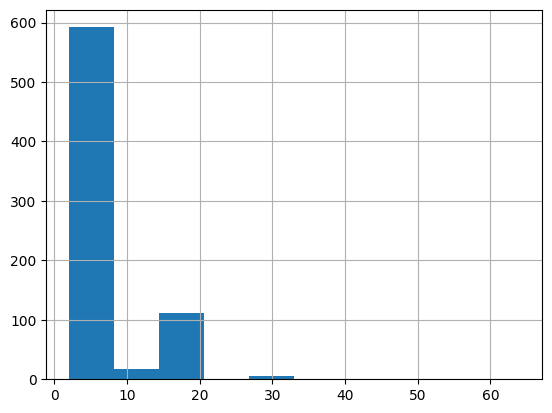

In [43]:
train_set["Ram_int"].hist();

<Axes: >

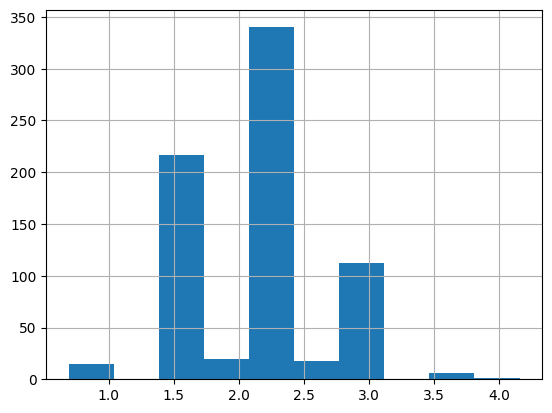

In [44]:
train_set["Ram_int"].transform("log").hist()

In [45]:
train_set["Ram_int"].transform("log").describe()

count    729.000000
mean       1.967462
std        0.521811
min        0.693147
25%        1.386294
50%        2.079442
75%        2.079442
max        4.158883
Name: Ram_int, dtype: float64

In [46]:
std_scaler = StandardScaler()

train_set["Ram_scaled"] = std_scaler.fit_transform(pd.DataFrame(train_set.Ram_int.transform("log")))
test_set["Ram_scaled"] = std_scaler.transform(pd.DataFrame(test_set.Ram_int.transform("log")))
real_test["Ram_scaled"] = std_scaler.transform(pd.DataFrame(real_test.Ram_int.transform("log")))


In [47]:
features.append("Ram_scaled")

#### Variable `CPU`
Esta variable tiene tantos datos que se clasifica como numérica discreta, cuando es claramente categórica. Vamos a sacar sólo la información esencial que más pueda afectar al precio.

In [48]:
train_set.loc[train_set.Cpu.str.contains("Intel", regex=False), "Cpu"].count()

np.int64(698)

In [49]:
train_set["Cpu_brand"] = train_set.Cpu.str.contains("Intel", regex=False).map({True:"Intel", False:np.nan})

test_set["Cpu_brand"] = test_set.Cpu.str.contains("Intel", regex=False).map({True:"Intel", False:np.nan})
real_test["Cpu_brand"] = real_test.Cpu.str.contains("Intel", regex=False).map({True:"Intel", False:np.nan})

In [50]:
train_set["Cpu_brand"].value_counts(dropna=False)

Cpu_brand
Intel    698
NaN       31
Name: count, dtype: int64

In [51]:
train_set.loc[train_set.Cpu_brand.isna(), "Cpu_brand"] = train_set.loc[train_set.Cpu_brand.isna(), "Cpu"].str.contains("AMD", regex=False).map({True:"AMD", False:np.nan})

In [52]:
train_set.Cpu_brand.value_counts(dropna=False)

Cpu_brand
Intel    698
AMD       31
Name: count, dtype: int64

Sólo tenemos dos categorías, vamos a transdormarla en una variable binaria de 0,1.

In [53]:
train_set["Cpu_Intel"] = train_set.Cpu.str.contains("Intel", regex=False).astype(int)

test_set["Cpu_Intel"] = test_set.Cpu.str.contains("Intel", regex=False).astype(int)
real_test["Cpu_Intel"] = real_test.Cpu.str.contains("Intel", regex=False).astype(int)

In [54]:
train_set.drop(columns="Cpu_brand", inplace=True)

In [55]:
train_set.Cpu_Intel.value_counts(True)

Cpu_Intel
1    0.957476
0    0.042524
Name: proportion, dtype: float64

In [56]:
features.append("Cpu_Intel")

In [57]:
# Sacamos la generación de las CPUs, sabiendo que existe una equivalencia entre Intel y AMD
import re

def generacion_cpu(cpu):
    cpu = str(cpu)

    if "Intel Core M" in cpu:   # Aquí hay dos modelos
        modelo_y = re.search(r"\b\dY\d{2}\b", cpu)
        modelo_my = re.search(r"\bm\d-\dY\d{2}\b", cpu, re.IGNORECASE)  # estos separan con -

        if modelo_y:
            return int(modelo_y.group()[0]) # El primer valor es la gen
        elif modelo_my:
            return int(modelo_my.group().split("-")[1][0])
        else:
            return 6

    elif "Intel Core" in cpu:
        modelo = re.search(r"\b\d{4}[A-Z]*\b", cpu)
        modelo_y = re.search(r"\b\dY\d{2}\b", cpu)

        if modelo:
            return int(modelo.group()[0])
        elif modelo_y:
            return int(modelo_y.group()[0])
        else:
            return 6

    elif "Ryzen" in cpu:
        return 8

    elif re.search(r"\b(A12|A10|A9|FX)\b", cpu):
        return 7

    elif re.search(r"\b(A8|A6)\b", cpu):
        return 6

    elif "E-Series" in cpu:
        return 5

    elif "Xeon" in cpu:
        if re.search(r"\b[Vv]6\b", cpu):
            return 7
        elif re.search(r"\b[Vv]5\b", cpu):
            return 6
        else:
            return 6

    elif re.search(r"\b(Celeron|Pentium|Atom)\b", cpu):
        return 5
    
    elif "A4-Series" in cpu:
        return 5

    elif "Cortex" in cpu or "Samsung" in cpu:
        return 4

    else:
        return np.nan

In [58]:
train_set["Cpu_gen"] = train_set["Cpu"].apply(generacion_cpu)

test_set["Cpu_gen"] = test_set["Cpu"].apply(generacion_cpu)
real_test["Cpu_gen"] = real_test["Cpu"].apply(generacion_cpu)

In [59]:
train_set["Cpu_gen"].value_counts(dropna=False)

Cpu_gen
7    343
6    210
8     89
5     87
Name: count, dtype: int64

In [60]:
features.append("Cpu_gen")

#### Variable `GPU`

In [61]:
train_set["Gpu"].value_counts(dropna=False)

Gpu
Intel HD Graphics 620      150
Intel HD Graphics 520      110
Intel UHD Graphics 620      43
Nvidia GeForce GTX 1050     32
Nvidia GeForce 940MX        24
                          ... 
Nvidia GeForce GTX 940M      1
Intel HD Graphics 620        1
Intel HD Graphics 5300       1
Nvidia Quadro M2000M         1
AMD R17M-M1-70               1
Name: count, Length: 84, dtype: int64

In [62]:
train_set["Gpu_brand"] = train_set.Gpu.str.contains("Intel", regex=False).map({True:"Intel", False:np.nan})
test_set["Gpu_brand"] = test_set.Gpu.str.contains("Intel", regex=False).map({True:"Intel", False:np.nan})
real_test["Gpu_brand"] = real_test.Gpu.str.contains("Intel", regex=False).map({True:"Intel", False:np.nan})

In [63]:
train_set.loc[train_set.Gpu_brand.isna(), "Gpu_brand"] = train_set.loc[train_set.Gpu_brand.isna(), "Gpu"].str.contains("AMD", regex=False).map({True:"AMD", False:np.nan})
train_set.loc[train_set.Gpu_brand.isna(), "Gpu_brand"] = train_set.loc[train_set.Gpu_brand.isna(), "Gpu"].str.contains("Nvidia", regex=False).map({True:"Nvidia", False:np.nan})

test_set.loc[test_set.Gpu_brand.isna(), "Gpu_brand"] = test_set.loc[test_set.Gpu_brand.isna(), "Gpu"].str.contains("AMD", regex=False).map({True:"AMD", False:np.nan})
test_set.loc[test_set.Gpu_brand.isna(), "Gpu_brand"] = test_set.loc[test_set.Gpu_brand.isna(), "Gpu"].str.contains("Nvidia", regex=False).map({True:"Nvidia", False:np.nan})

real_test.loc[real_test.Gpu_brand.isna(), "Gpu_brand"] = real_test.loc[real_test.Gpu_brand.isna(), "Gpu"].str.contains("AMD", regex=False).map({True:"AMD", False:np.nan})
real_test.loc[real_test.Gpu_brand.isna(), "Gpu_brand"] = real_test.loc[real_test.Gpu_brand.isna(), "Gpu"].str.contains("Nvidia", regex=False).map({True:"Nvidia", False:np.nan})

In [64]:
train_set["Gpu_brand"].value_counts(dropna=False)

Gpu_brand
Intel     417
Nvidia    220
AMD        92
Name: count, dtype: int64

In [65]:
pd.get_dummies(train_set["Gpu_brand"], prefix="Gpu_", drop_first=True).astype(int)

,Gpu__Intel,Gpu__Nvidia
25,0,0
84,0,1
10,1,0
342,1,0
890,0,0
...,...,...
106,1,0
270,0,0
860,1,0
435,1,0


In [66]:
train_set[["Gpu__Intel","Gpu__Nvidia"]] = pd.get_dummies(train_set["Gpu_brand"], prefix="Gpu_", drop_first=True).astype(int)
test_set[["Gpu__Intel","Gpu__Nvidia"]] = pd.get_dummies(test_set["Gpu_brand"], prefix="Gpu_", drop_first=True).astype(int)
real_test[["Gpu__Intel","Gpu__Nvidia"]] = pd.get_dummies(real_test["Gpu_brand"], prefix="Gpu_", drop_first=True).astype(int)

In [67]:
train_set[["Gpu__Intel","Gpu__Nvidia"]].sample(10)

,Gpu__Intel,Gpu__Nvidia
676,0,1
359,0,1
838,0,1
262,1,0
460,1,0
741,0,1
223,0,1
632,1,0
605,0,1
790,1,0


In [68]:
features.extend(["Gpu__Intel","Gpu__Nvidia"])

Vamos a hacer una codificación similar a las de Cpu, esta vez con similitudes en potencia gráfica.

In [69]:
def nivel_gpu(gpu):
    gpu = str(gpu)

    if "GTX" in gpu:
        if re.search(r"1080|1070", gpu):
            return 5
        elif re.search(r"1060|1050|980|970", gpu):
            return 4
        elif re.search(r"965|960|950", gpu):
            return 3
        else:
            return 3

    elif "MX" in gpu:
        if re.search(r"150|130", gpu):
            return 3
        elif re.search(r"110", gpu):
            return 2
        else:
            return 2

    elif "Nvidia" in gpu or "GeForce" in gpu:
        if re.search(r"940|930|920", gpu):
            return 2
        else:
            return 2

    elif "Intel" in gpu:
        return 1

    elif "Radeon" in gpu or "AMD" in gpu:
        if re.search(r"RX\s?580", gpu):
            return 5
        elif re.search(r"RX\s?560|RX\s?550|Pro", gpu):
            return 4
        elif re.search(r"540|530", gpu):
            return 3
        elif re.search(r"520|R7|R5|R17M", gpu):
            return 2
        elif re.search(r"R4|R3|R2", gpu):
            return 1
        else:
            return 2

    elif "Quadro" in gpu or "FirePro" in gpu:
        return 4

    elif "Mali" in gpu or "ARM" in gpu:
        return 1

    else:
        return np.nan

In [70]:
train_set["Gpu_level"] = train_set["Gpu"].apply(nivel_gpu)

test_set["Gpu_level"] = test_set["Gpu"].apply(nivel_gpu)
real_test["Gpu_level"] = real_test["Gpu"].apply(nivel_gpu)

In [71]:
train_set["Gpu_level"].value_counts(dropna=False)

Gpu_level
1    430
2    123
4     96
3     55
5     25
Name: count, dtype: int64

In [72]:
features.append("Gpu_level")

#### Variable `ScreenResolution`

In [73]:
raw_num

['Product', 'Cpu', 'Weight', 'ScreenResolution', 'Memory', 'Gpu', 'Company']

In [74]:
train_set['ScreenResolution'].sample(10)

781             1366x768
36              1366x768
115    Full HD 1920x1080
129             1366x768
651    Full HD 1920x1080
900    Full HD 1920x1080
774    Full HD 1920x1080
262    Full HD 1920x1080
112             1366x768
822             1366x768
Name: ScreenResolution, dtype: object

In [75]:
train_set["Touchscreen"] = train_set["ScreenResolution"].str.contains("Touchscreen").astype(int)
test_set["Touchscreen"] = test_set["ScreenResolution"].str.contains("Touchscreen").astype(int)
real_test["Touchscreen"] = real_test["ScreenResolution"].str.contains("Touchscreen").astype(int)

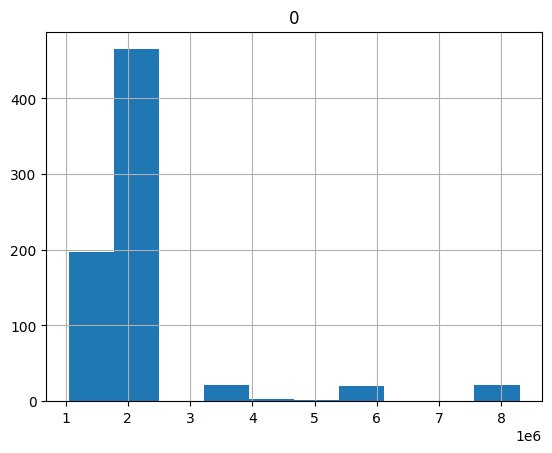

In [76]:
(train_set["ScreenResolution"].str.extract(r"(\d+)x\d+").astype(int) * train_set["ScreenResolution"].str.extract(r"\d+x(\d+)").astype(int)).hist();

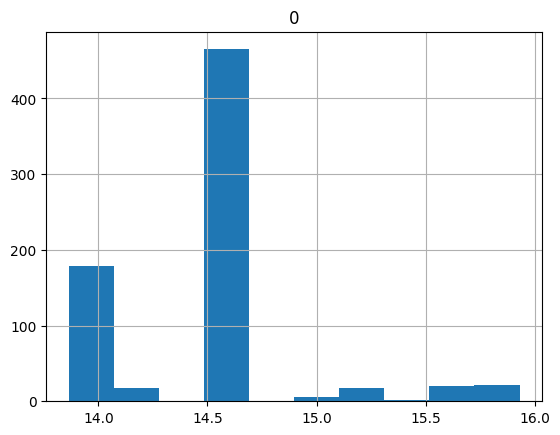

In [77]:
(train_set["ScreenResolution"].str.extract(r"(\d+)x\d+").astype(int) * train_set["ScreenResolution"].str.extract(r"\d+x(\d+)").astype(int)).transform("log").hist();

In [78]:
# Vamos a sacar una única variable de pixels de resolución
std_scaler = StandardScaler()
train_set["Screen_pixels"] = std_scaler.fit_transform(pd.DataFrame(\
    (train_set["ScreenResolution"].str.extract(r"(\d+)x\d+").astype(int) * train_set["ScreenResolution"].str.extract(r"\d+x(\d+)").astype(int)).transform("log")))

test_set["Screen_pixels"] = std_scaler.transform(pd.DataFrame(\
    (test_set["ScreenResolution"].str.extract(r"(\d+)x\d+").astype(int) * test_set["ScreenResolution"].str.extract(r"\d+x(\d+)").astype(int)).transform("log")))

real_test["Screen_pixels"] = std_scaler.transform(pd.DataFrame(\
    (real_test["ScreenResolution"].str.extract(r"(\d+)x\d+").astype(int) * real_test["ScreenResolution"].str.extract(r"\d+x(\d+)").astype(int)).transform("log")))

In [79]:
features.extend(["Touchscreen", "Screen_pixels"])

#### Variable `Company`

In [80]:
train_set['Company'].sample(10)

0           HP
21        Dell
647       Dell
624        MSI
447     Lenovo
829    Fujitsu
83          HP
212     Lenovo
478     Google
911       Dell
Name: Company, dtype: object

In [81]:
train_set['Company'].value_counts(True)

Company
Lenovo       0.222222
Dell         0.216735
HP           0.212620
Asus         0.138546
Acer         0.075446
Toshiba      0.042524
MSI          0.041152
Apple        0.017833
Mediacom     0.005487
Razer        0.005487
Xiaomi       0.004115
Samsung      0.004115
Microsoft    0.004115
Google       0.002743
Fujitsu      0.002743
Vero         0.002743
Chuwi        0.001372
Name: proportion, dtype: float64

In [82]:
var_cat = "Company"
clases = [clase for clase in train_set[var_cat].unique()]
grupos = [train_set.loc[train_set[var_cat] == clase][target] for clase in clases]
pobs_significativas = set()

for i, grupo1 in enumerate(grupos):
    for j in range(i+1, len(grupos)):
        u_stat, p_valor = mannwhitneyu(grupo1, grupos[j])
        if p_valor < 0.05:
            pobs_significativas.add(tuple(set([clases[i], clases[j]])))

In [83]:
company_count = dict(zip(train_set['Company'].unique().tolist(), [0,]*17))
for par in pobs_significativas:
    company_count[par[0]] += 1
    company_count[par[1]] += 1

company_sorted = pd.Series(company_count).sort_values(ascending=False)

In [84]:
company_sorted

Acer         14
Mediacom      9
MSI           9
Vero          8
Toshiba       8
Apple         8
HP            7
Lenovo        7
Dell          7
Razer         7
Asus          7
Samsung       4
Fujitsu       2
Google        1
Microsoft     1
Xiaomi        1
Chuwi         0
dtype: int64

<Axes: >

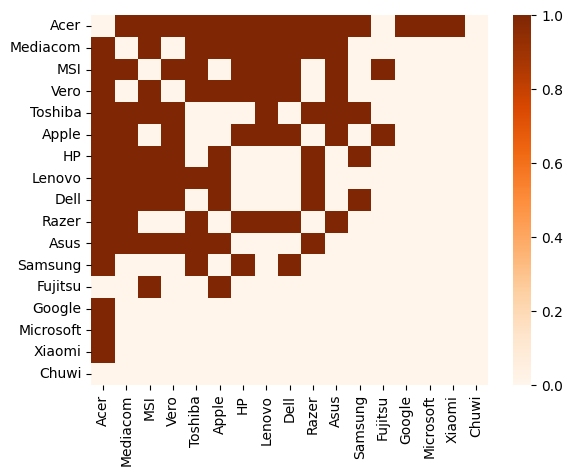

In [85]:
company_vals = pd.DataFrame(np.zeros([17, 17], dtype=int), columns=company_sorted.index, index=company_sorted.index)

for par in pobs_significativas:
    company_vals[par[0]][par[1]] = 1
    company_vals[par[1]][par[0]] = 1

sns.heatmap(company_vals, cmap="Oranges")

Queremos quedarnos con las marcas más significativas, y eliminar las menos. En grupos de variables con significaciones similares, se trata de elegir un único representante del grupo.

In [86]:
elegidas = company_sorted.loc[company_sorted > 6].index.tolist()

In [87]:
def clean_company(name):
    name=str(name)

    if name not in elegidas:
        return "Other"
        
    else:
        return name

    

In [88]:
train_set["Company_clean"] = train_set.Company.apply(clean_company)

test_set["Company_clean"] = test_set.Company.apply(clean_company)
real_test["Company_clean"] = real_test.Company.apply(clean_company)

In [89]:
features.append("Company_clean")

#### Variable `Inches`

In [90]:
train_set.Inches.describe()

count    729.000000
mean      15.002881
std        1.428711
min       10.100000
25%       14.000000
50%       15.600000
75%       15.600000
max       17.300000
Name: Inches, dtype: float64

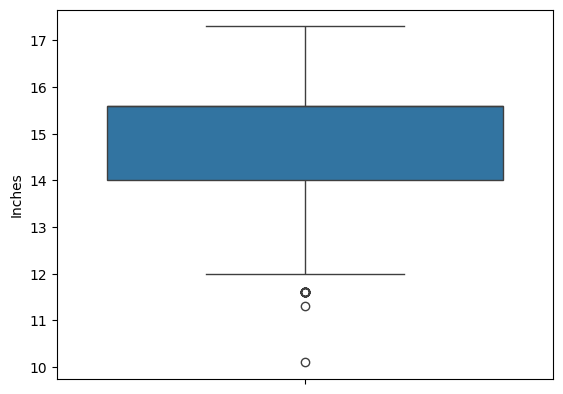

In [91]:
sns.boxplot(train_set.Inches);

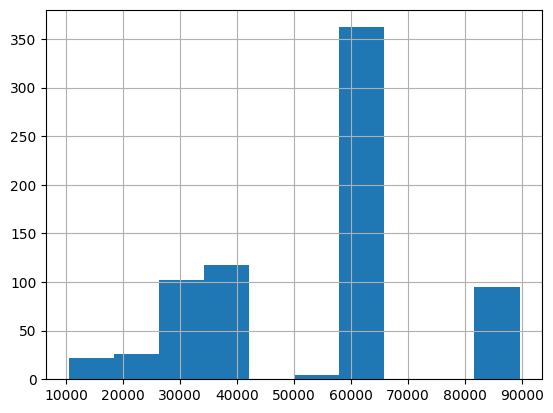

In [92]:
# Podemos compensar la asimetría por medio de una potencia
train_set.Inches.transform(lambda x: x**4).hist();

In [93]:
train_set.Inches.transform(lambda x: x**4).describe()

count      729.000000
mean     53362.613573
std      19029.226837
min      10406.040100
25%      38416.000000
50%      59224.089600
75%      59224.089600
max      89574.504100
Name: Inches, dtype: float64

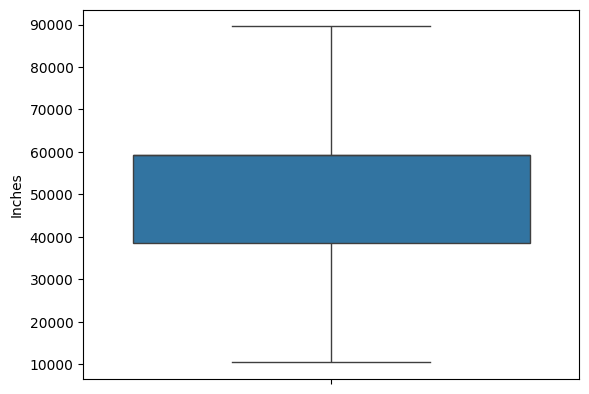

In [94]:
sns.boxplot(train_set.Inches.transform(lambda x: x**4));

In [95]:
std_scaler = StandardScaler()
train_set["Inches_p4"] = std_scaler.fit_transform(pd.DataFrame(train_set.Inches.transform(lambda x: x**4)))
test_set["Inches_p4"] = std_scaler.transform(pd.DataFrame(test_set.Inches.transform(lambda x: x**4)))
real_test["Inches_p4"] = std_scaler.transform(pd.DataFrame(real_test.Inches.transform(lambda x: x**4)))

In [96]:
train_set["Inches_p4"].describe()

count    7.290000e+02
mean     5.945556e-16
std      1.000687e+00
min     -2.258950e+00
25%     -7.859949e-01
50%      3.082364e-01
75%      3.082364e-01
max      1.904268e+00
Name: Inches_p4, dtype: float64

In [97]:
features.append("Inches_p4")

#### Variable `Memory`

In [98]:
train_set.Memory.value_counts()

Memory
256GB SSD                 226
1TB HDD                   122
500GB HDD                  80
512GB SSD                  62
128GB SSD +  1TB HDD       56
128GB SSD                  45
256GB SSD +  1TB HDD       43
32GB Flash Storage         23
1TB SSD                     8
64GB Flash Storage          8
256GB Flash Storage         7
512GB SSD +  1TB HDD        6
256GB SSD +  2TB HDD        6
2TB HDD                     6
16GB Flash Storage          4
128GB Flash Storage         4
1.0TB Hybrid                3
32GB SSD                    3
512GB SSD +  2TB HDD        2
180GB SSD                   2
8GB SSD                     1
1TB SSD +  1TB HDD          1
128GB HDD                   1
240GB SSD                   1
512GB Flash Storage         1
512GB SSD +  512GB SSD      1
1TB HDD +  1TB HDD          1
1.0TB HDD                   1
256GB SSD +  256GB SSD      1
16GB SSD                    1
128GB SSD +  2TB HDD        1
508GB Hybrid                1
64GB SSD                    1
Nam

Hay 4 tipos distintos: SSD, HDD, Flash Storage y Hybrid, y algunos tienen combinaciónd e SSD y HDD

In [99]:
train_set["Memory_SSD"] = train_set.Memory.str.contains("SSD", regex=False).astype(int)
test_set["Memory_SSD"] = test_set.Memory.str.contains("SSD", regex=False).astype(int)
real_test["Memory_SSD"] = real_test.Memory.str.contains("SSD", regex=False).astype(int)

In [100]:
train_set["Memory_HDD"] = train_set.Memory.str.contains("HDD", regex=False).astype(int)
test_set["Memory_HDD"] = test_set.Memory.str.contains("HDD", regex=False).astype(int)
real_test["Memory_HDD"] = real_test.Memory.str.contains("HDD", regex=False).astype(int)

In [101]:
train_set["Memory_FlashStorage"] = train_set.Memory.str.contains("Flash Storage", regex=False).astype(int)
test_set["Memory_FlashStorage"] = test_set.Memory.str.contains("Flash Storage", regex=False).astype(int)
real_test["Memory_FlashStorage"] = real_test.Memory.str.contains("Flash Storage", regex=False).astype(int)

In [102]:
features.extend(["Memory_SSD", "Memory_HDD","Memory_FlashStorage"])

In [103]:
# Nos falta el tamaño de memoria

def tb_to_gb(memoria):
    memoria = str(memoria)

    total = 0

    capacidades = re.findall(r"(\d+)(GB|TB)", memoria)

    for numero, unidad in capacidades:
        numero = int(numero)

        if unidad == "TB":
            total += numero * 1024
        else:
            total += numero

    return total 

In [104]:
train_set["Memory_size"] = train_set.Memory.apply(tb_to_gb)
test_set["Memory_size"] = test_set.Memory.apply(tb_to_gb)
real_test["Memory_size"] = real_test.Memory.apply(tb_to_gb)

In [105]:
train_set.Memory_size.describe()

count     729.000000
mean      606.085048
std       476.157881
min         0.000000
25%       256.000000
50%       500.000000
75%      1024.000000
max      2560.000000
Name: Memory_size, dtype: float64

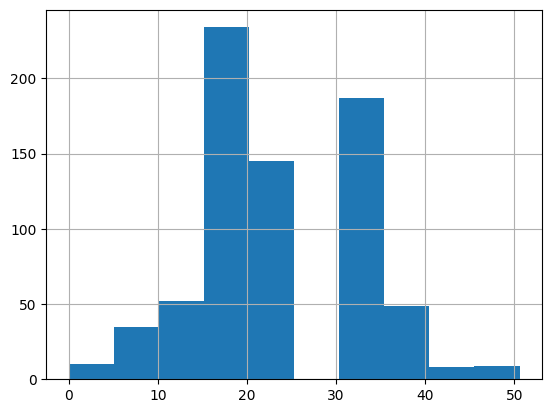

In [106]:
train_set.Memory_size.transform("sqrt").hist();

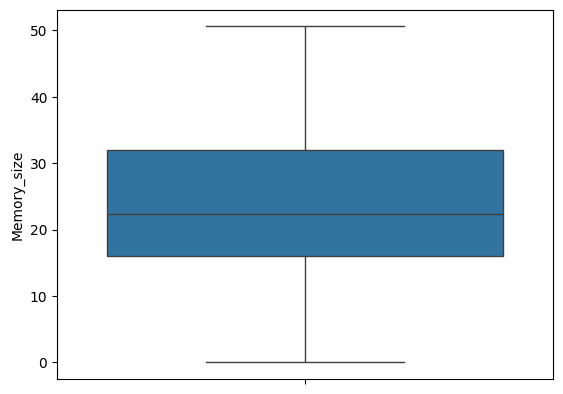

In [107]:
sns.boxplot(train_set.Memory_size.transform("sqrt"));

In [108]:
std_scaler = StandardScaler()
train_set["Memory_GB_sqrt"] = std_scaler.fit_transform(pd.DataFrame(train_set.Memory_size.transform("sqrt")))
test_set["Memory_GB_sqrt"] = std_scaler.transform(pd.DataFrame(test_set.Memory_size.transform("sqrt")))
real_test["Memory_GB_sqrt"] = std_scaler.transform(pd.DataFrame(real_test.Memory_size.transform("sqrt")))

In [109]:
train_set.Memory_GB_sqrt.describe()

count    7.290000e+02
mean    -1.790977e-16
std      1.000687e+00
min     -2.338474e+00
25%     -6.855470e-01
50%     -2.843833e-02
75%      9.673800e-01
max      2.888540e+00
Name: Memory_GB_sqrt, dtype: float64

In [110]:
features.append("Memory_GB_sqrt")

#### Variable `Weight`

In [111]:
train_set.Weight.sample(10)

14      1.88kg
707    0.920kg
795      1.1kg
889     1.26kg
688      2.8kg
94      1.36kg
10      1.37kg
1       2.59kg
868      1.9kg
280     1.54kg
Name: Weight, dtype: object

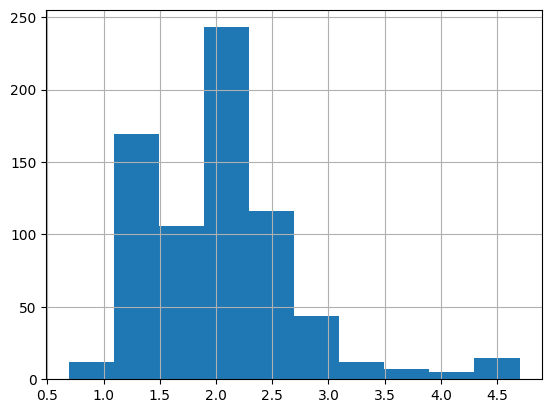

In [112]:
(train_set["Weight"].str.replace("kg", "").astype(float)).hist();

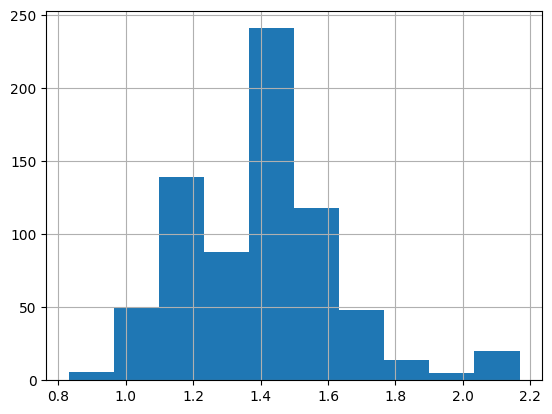

In [113]:
(train_set["Weight"].str.replace("kg", "").astype(float)).transform("sqrt").hist();

In [114]:
std_scaler = StandardScaler()
train_set["Weight"] = std_scaler.fit_transform(pd.DataFrame((train_set["Weight"].str.replace("kg", "").astype(float)).transform("sqrt")))
test_set["Weight"] = std_scaler.transform(pd.DataFrame((test_set["Weight"].str.replace("kg", "").astype(float)).transform("sqrt")))
real_test["Weight"] = std_scaler.transform(pd.DataFrame((real_test["Weight"].str.replace("kg", "").astype(float)).transform("sqrt")))

In [115]:
train_set["Weight"].describe()

count    7.290000e+02
mean     4.093662e-16
std      1.000687e+00
min     -2.567831e+00
25%     -8.158138e-01
50%      8.909096e-02
75%      4.816093e-01
max      3.377494e+00
Name: Weight, dtype: float64

In [116]:
features.append("Weight")

#### Variable `Product`
Parece que la información de esta variable es una mezcla de las demás variables dependiendo de la marca, por lo que se va a optar por excluirla del estudio.

In [117]:
train_set[raw_num[2]].sample(10)

131    3.022331
26     0.976459
300    0.333406
321    0.333406
93     0.026529
138   -0.052560
796   -1.705198
797    0.481609
246   -0.963003
679    3.274408
Name: Weight, dtype: float64

In [118]:
for feature in features:
    print(train_set[feature].describe(), end="\n"*2)

count    729.000000
mean       2.603567
std        1.215983
min        0.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        5.000000
Name: ordinal_TypeName, dtype: float64

count    729.000000
mean       0.857339
std        0.349967
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: OpSys_Windows, dtype: float64

count    729.000000
mean       0.017833
std        0.132434
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: OpSys_Mac, dtype: float64

count    729.000000
mean       0.050754
std        0.219647
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: OpSys_Linux, dtype: float64

count    729.000000
mean       0.053498
std        0.225179
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: OpSys_None, dtype: float64

count    7.290000e+02

In [119]:
features, len(features)

(['ordinal_TypeName',
  'OpSys_Windows',
  'OpSys_Mac',
  'OpSys_Linux',
  'OpSys_None',
  'Ram_scaled',
  'Cpu_Intel',
  'Cpu_gen',
  'Gpu__Intel',
  'Gpu__Nvidia',
  'Gpu_level',
  'Touchscreen',
  'Screen_pixels',
  'Company_clean',
  'Inches_p4',
  'Memory_SSD',
  'Memory_HDD',
  'Memory_FlashStorage',
  'Memory_GB_sqrt',
  'Weight'],
 20)

### 3.1 Separación X e y

In [120]:
X_train = train_set[features].copy()
y_train = train_set[target].copy()

X_test = test_set[features].copy()
y_test = test_set[target].copy()

In [121]:
X_real_test = real_test[features].copy()

In [122]:
features

['ordinal_TypeName',
 'OpSys_Windows',
 'OpSys_Mac',
 'OpSys_Linux',
 'OpSys_None',
 'Ram_scaled',
 'Cpu_Intel',
 'Cpu_gen',
 'Gpu__Intel',
 'Gpu__Nvidia',
 'Gpu_level',
 'Touchscreen',
 'Screen_pixels',
 'Company_clean',
 'Inches_p4',
 'Memory_SSD',
 'Memory_HDD',
 'Memory_FlashStorage',
 'Memory_GB_sqrt',
 'Weight']

In [123]:
features_num = features.copy()
features_num.remove("Company_clean")

In [124]:
X_train_num = train_set[features_num].copy()
X_test_num = test_set[features_num].copy()

## 4. Modelado

### 4.1 Entrenamiento

In [125]:
reg_models = {
    "LinearRegression": LinearRegression(),
    "KNN_k5": KNeighborsRegressor(n_neighbors = 5),
    "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state = 42),
    "RandomForest": RandomForestRegressor(n_estimators = 200, max_depth=5, random_state = 42, n_jobs = -1),
    "XGBoost": XGBRegressor(random_state = 42),
    "Light GBM": LGBMRegressor(random_state= 42, verbose = -100)
}


In [126]:
metricas_cv_reg = {}
valores_reg = []

for nombre, regresor in reg_models.items():
    print(regresor)
    metricas_cv_reg[nombre] = cross_val_score(regresor, X_train_num, y_train, cv = 5, scoring = "neg_root_mean_squared_error")
    valores_reg.append(np.mean(metricas_cv_reg[nombre]))
ganador_reg = list(metricas_cv_reg.keys())[np.argmax(valores_reg)]

LinearRegression()
KNeighborsRegressor()
DecisionTreeRegressor(max_depth=5, random_state=42)
RandomForestRegressor(max_depth=5, n_estimators=200, n_jobs=-1, random_state=42)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
LGBMRegressor(random_state=42, verbose=-100)


In [127]:
for model_name, valores_reg in metricas_cv_reg.items():
    print(f"Model <{model_name}>, RMSE_CV: {-np.mean(valores_reg)}, Reversed_log: {np.exp(-np.mean(valores_reg))}")
print(f"El ganador es {ganador_reg}")

Model <LinearRegression>, RMSE_CV: 0.3128394459051987, Reversed_log: 1.3673019874708499
Model <KNN_k5>, RMSE_CV: 0.2607560877164023, Reversed_log: 1.297911050373905
Model <DecisionTree>, RMSE_CV: 0.28239374419883534, Reversed_log: 1.3263008404509324
Model <RandomForest>, RMSE_CV: 0.26193541658794517, Reversed_log: 1.2994426172813311
Model <XGBoost>, RMSE_CV: 0.23867390419503112, Reversed_log: 1.2695644694271067
Model <Light GBM>, RMSE_CV: 0.23785312843919026, Reversed_log: 1.268522869208702
El ganador es Light GBM


### 4.2 Métricas y Optimización

Recuerda que en la competición se evalúa con **RMSE**.

Vamos a probar optuna con LightGBM

In [128]:
def objective(trial):

    params = { "n_estimators": trial.suggest_int("n_estimators", 100, 1500),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "num_leaves": trial.suggest_int("num_leaves", 20, 150),
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1
            }

    model = LGBMRegressor(**params)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train_num,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()

In [129]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-07-02 20:23:30,097] A new study created in memory with name: no-name-2d57ddf6-ff43-4e0f-b53d-deb0638fcf84
[I 2026-07-02 20:23:36,791] Trial 0 finished with value: 0.30455548010440764 and parameters: {'n_estimators': 713, 'learning_rate': 0.03683251044139203, 'num_leaves': 56, 'max_depth': 3, 'min_child_samples': 87, 'subsample': 0.7435348814622038, 'colsample_bytree': 0.5961843625008489, 'reg_alpha': 0.6028514665719886, 'reg_lambda': 7.731141848395737}. Best is trial 0 with value: 0.30455548010440764.
[I 2026-07-02 20:23:43,428] Trial 1 finished with value: 0.33194714253189056 and parameters: {'n_estimators': 793, 'learning_rate': 0.08578545152324166, 'num_leaves': 139, 'max_depth': 18, 'min_child_samples': 92, 'subsample': 0.5700683316165779, 'colsample_bytree': 0.576531824368862, 'reg_alpha': 8.296410443316333, 'reg_lambda': 8.80984715691393}. Best is trial 0 with value: 0.30455548010440764.
[I 2026-07-02 20:23:49,892] Trial 2 finished with value: 0.30491761337892437 and para

In [130]:
study.best_params

{'n_estimators': 829,
 'learning_rate': 0.11000050979251673,
 'num_leaves': 52,
 'max_depth': 15,
 'min_child_samples': 18,
 'subsample': 0.6959938684464356,
 'colsample_bytree': 0.6501087741617125,
 'reg_alpha': 0.03188876688019704,
 'reg_lambda': 9.890351759658033}

In [131]:
study.best_value

0.2177981847038884

In [132]:
best_params = study.best_params

best_model = LGBMRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

best_model.fit(X_train_num, y_train)

,num_leaves,52
,max_depth,15
,learning_rate,0.11000050979251673
,n_estimators,829
,min_child_samples,18
,subsample,0.6959938684464356
,colsample_bytree,0.6501087741617125
,reg_alpha,0.03188876688019704
,reg_lambda,9.890351759658033
,random_state,42
,n_jobs,-1


In [133]:
y_pred = best_model.predict(X_test_num)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_exp = np.sqrt(mean_squared_error(test_set[original_target], np.exp(y_pred)))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("CV RMSE:", study.best_value)
print("Test RMSE:", rmse)
print("Test exp RMSE:", rmse_exp)
print("Test MAE:", mae)
print("Test R2:", r2)

CV RMSE: 0.2177981847038884
Test RMSE: 0.23044258676702903
Test exp RMSE: 310.3364931304732
Test MAE: 0.17196135750392888
Test R2: 0.8840317443327707


In [ ]:
y_train_pred = best_model.predict(X_train_num)
y_test_pred = best_model.predict(X_test_num)

print("Train exp RMSE:", np.sqrt(mean_squared_error(train_set[original_target], np.exp(y_train_pred)))) # un poco de overfitting JAJAJAJA
print("Test exp RMSE:", np.sqrt(mean_squared_error(test_set[original_target], np.exp(y_test_pred))))

Train exp RMSE: 119.72204594567081
Test exp RMSE: 310.3364931304732


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [135]:
X_real_train = pd.concat([X_train_num, X_test_num])
y_real_train = pd.concat([y_train, y_test])

In [136]:
study.best_params, study.best_value

({'n_estimators': 829,
  'learning_rate': 0.11000050979251673,
  'num_leaves': 52,
  'max_depth': 15,
  'min_child_samples': 18,
  'subsample': 0.6959938684464356,
  'colsample_bytree': 0.6501087741617125,
  'reg_alpha': 0.03188876688019704,
  'reg_lambda': 9.890351759658033},
 0.2177981847038884)

In [137]:
best_params = study.best_params

best_model = LGBMRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [138]:
best_model.fit(X_real_train, y_real_train)

,num_leaves,52
,max_depth,15
,learning_rate,0.11000050979251673
,n_estimators,829
,min_child_samples,18
,subsample,0.6959938684464356
,colsample_bytree,0.6501087741617125
,reg_alpha,0.03188876688019704
,reg_lambda,9.890351759658033
,random_state,42
,n_jobs,-1


---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

In [139]:
X_real_test = real_test[features_num].copy()

In [140]:
y_pred = best_model.predict(X_real_test)
y_pred_exp = np.exp(y_pred)

In [141]:
len(y_pred), len(y_pred_exp)

(391, 391)

## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [142]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [143]:
submission_LGBM = pd.concat([real_test.laptop_ID, pd.Series(y_pred_exp, name="Price_in_euros")], axis=1)

In [144]:
submission_LGBM.sample()

,laptop_ID,Price_in_euros
82,445,2449.290564


In [145]:
len(submission_LGBM), len(real_test)

(391, 391)

### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [146]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [147]:
checker(submission_LGBM, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260702_202443.csv'. ¡A Kaggle!
